In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

In [2]:
import pandas as pd
import random

# Number of records
num_records = 200

# Sample data
genders = ["Male", "Female"]
blood_types = ["A+", "A-", "B+", "B-", "AB+", "AB-", "O+", "O-"]

medical_conditions = [
    "Diabetes",
    "Hypertension",
    "Heart Disease",
    "Asthma",
    "Migraine",
    "Dengue",
    "Typhoid",
    "Kidney Disease",
    "Cancer",
    "Pneumonia"
]

admission_types = [
    "Emergency",
    "Routine",
    "Urgent"
]

hospitals = [
    "Apollo Hospital",
    "Fortis Hospital",
    "City Hospital",
    "Green Care Hospital",
    "Sunrise Hospital"
]

doctors = [
    "Dr. Sharma",
    "Dr. Kumar",
    "Dr. Reddy",
    "Dr. Mehta",
    "Dr. Patel",
    "Dr. Singh"
]

insurance = [
    "Star Health",
    "HDFC Ergo",
    "ICICI Lombard",
    "Bajaj Allianz",
    "New India Assurance"
]

medications = {
    "Diabetes": ["Metformin", "Insulin"],
    "Hypertension": ["Amlodipine", "Losartan"],
    "Heart Disease": ["Aspirin", "Clopidogrel"],
    "Asthma": ["Salbutamol", "Budesonide"],
    "Migraine": ["Paracetamol", "Ibuprofen"],
    "Dengue": ["Paracetamol", "ORS"],
    "Typhoid": ["Azithromycin", "Cefixime"],
    "Kidney Disease": ["Losartan", "Furosemide"],
    "Cancer": ["Chemotherapy", "Radiotherapy"],
    "Pneumonia": ["Amoxicillin", "Azithromycin"]
}

test_results = ["Normal", "Abnormal", "Recovered", "Critical"]

# Create dataset
data = []

for i in range(1, num_records + 1):

    condition = random.choice(medical_conditions)

    row = {
        "Patient_ID": f"P{i:03}",
        "Age": random.randint(18, 80),
        "Gender": random.choice(genders),
        "Blood_Type": random.choice(blood_types),
        "Medical_Condition": condition,
        "Admission_Type": random.choice(admission_types),
        "Hospital": random.choice(hospitals),
        "Doctor": random.choice(doctors),
        "Insurance_Provider": random.choice(insurance),
        "Billing_Amount": random.randint(10000, 200000),
        "Medication": random.choice(medications[condition]),
        "Test_Result": random.choice(test_results),
        "Recovery_Days": random.randint(2, 40)
    }

    data.append(row)

# Convert to DataFrame
df = pd.DataFrame(data)

# Save dataset
df.to_csv("healthcare.csv", index=False)

print("Dataset generated successfully!")
print(df.head())

print("\nDataset Shape:", df.shape)

Dataset generated successfully!
  Patient_ID  Age  Gender Blood_Type Medical_Condition Admission_Type  \
0       P001   32    Male        AB+    Kidney Disease      Emergency   
1       P002   45  Female         O-     Heart Disease        Routine   
2       P003   19  Female         O-    Kidney Disease      Emergency   
3       P004   61    Male        AB+          Diabetes         Urgent   
4       P005   56  Female         B+            Asthma        Routine   

              Hospital     Doctor   Insurance_Provider  Billing_Amount  \
0      Fortis Hospital  Dr. Singh        Bajaj Allianz          152204   
1     Sunrise Hospital  Dr. Patel  New India Assurance           38154   
2     Sunrise Hospital  Dr. Reddy        Bajaj Allianz          156183   
3  Green Care Hospital  Dr. Singh        ICICI Lombard          190020   
4  Green Care Hospital  Dr. Kumar          Star Health          116835   

    Medication Test_Result  Recovery_Days  
0   Furosemide    Abnormal             3

In [3]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Patient_ID          200 non-null    object
 1   Age                 200 non-null    int64 
 2   Gender              200 non-null    object
 3   Blood_Type          200 non-null    object
 4   Medical_Condition   200 non-null    object
 5   Admission_Type      200 non-null    object
 6   Hospital            200 non-null    object
 7   Doctor              200 non-null    object
 8   Insurance_Provider  200 non-null    object
 9   Billing_Amount      200 non-null    int64 
 10  Medication          200 non-null    object
 11  Test_Result         200 non-null    object
 12  Recovery_Days       200 non-null    int64 
dtypes: int64(3), object(10)
memory usage: 20.4+ KB
None
              Age  Billing_Amount  Recovery_Days
count  200.000000      200.000000     200.000000
mean    49.655000   

In [4]:
df = df.drop_duplicates()

In [5]:
df = df.fillna(method='ffill')

/tmp/ipykernel_592/569672361.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [6]:
encoder = LabelEncoder()

categorical = df.select_dtypes(include='object').columns

for col in categorical:
    df[col] = encoder.fit_transform(df[col])

In [8]:
disease = df["Medical_Condition"].value_counts()

print(disease)

Medical_Condition
0    28
4    24
7    24
9    21
8    19
2    19
1    18
6    17
3    15
5    15
Name: count, dtype: int64


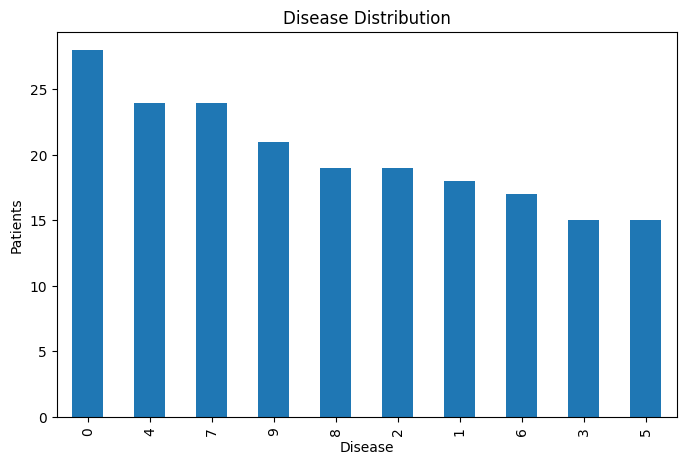

In [9]:
disease.plot(kind="bar", figsize=(8,5))

plt.title("Disease Distribution")

plt.xlabel("Disease")

plt.ylabel("Patients")

plt.show()

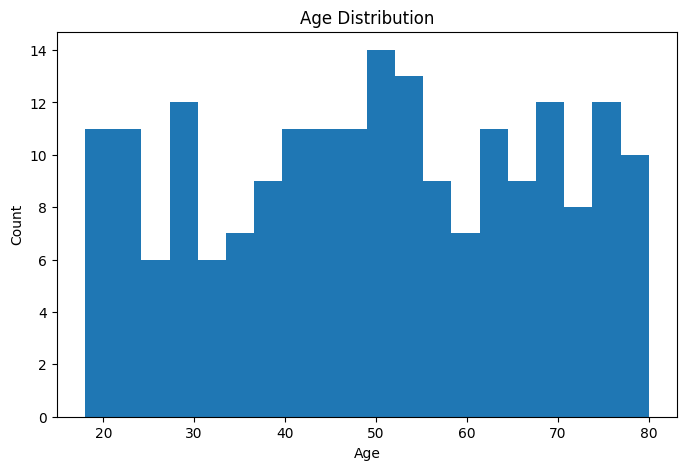

In [10]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=20)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

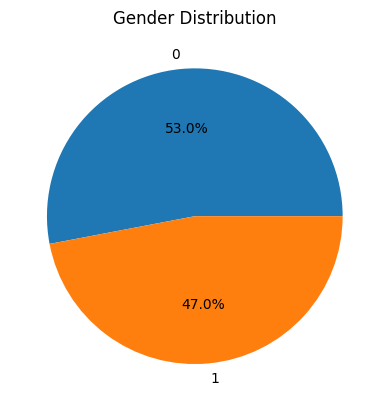

In [11]:
gender = df["Gender"].value_counts()

gender.plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")

plt.title("Gender Distribution")

plt.show()

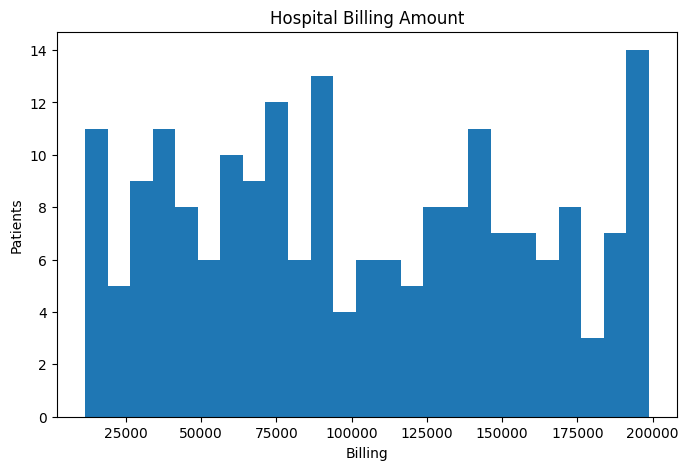

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df["Billing_Amount"], bins=25)

plt.title("Hospital Billing Amount")

plt.xlabel("Billing")

plt.ylabel("Patients")

plt.show()

Medical_Condition
0    116779.000000
1     93189.111111
2     79594.842105
3    118404.600000
4     70700.250000
5     92520.266667
6    113857.823529
7    107284.041667
8    125169.473684
9    112326.095238
Name: Billing_Amount, dtype: float64


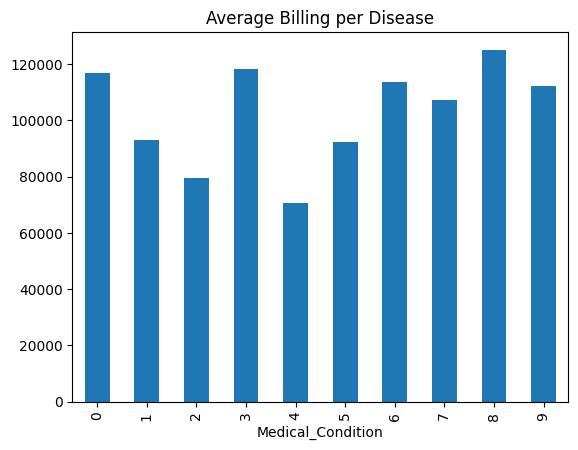

In [15]:
avg = df.groupby("Medical_Condition")["Billing_Amount"].mean()

print(avg)

avg.plot(kind="bar")

plt.title("Average Billing per Disease")

plt.show()

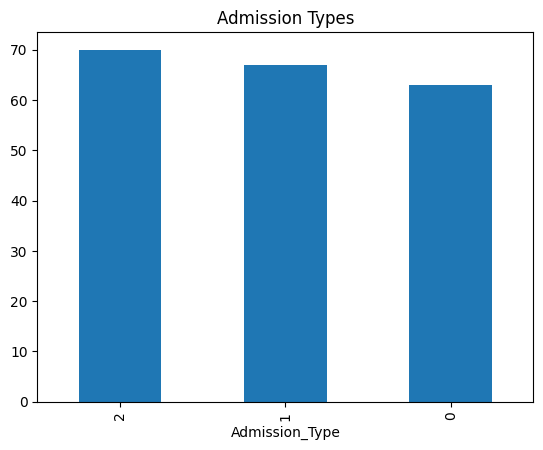

In [17]:
admission = df["Admission_Type"].value_counts()

admission.plot(kind="bar")

plt.title("Admission Types")

plt.show()

In [19]:
print("Average Age:",df["Age"].mean())

print("Average Billing:",df["Billing_Amount"].mean())

print("Most Common Disease:",
      df["Medical_Condition"].mode()[0])

print("Most Common Admission:",
      df["Admission_Type"].mode()[0])

Average Age: 49.655
Average Billing: 102838.325
Most Common Disease: 0
Most Common Admission: 2


In [21]:
print("------ Medical Insights ------")

print()

print("Most affected disease:",
      df["Medical_Condition"].mode()[0])

print()

print("Average patient age:",
      round(df["Age"].mean(),2))

print()

print("Average hospital bill:",
      round(df["Billing_Amount"].mean(),2))

print()

print("Highest billing:",
      df["Billing_Amount"].max())

print()

print("Lowest billing:",
      df["Billing_Amount"].min())

------ Medical Insights ------

Most affected disease: 0

Average patient age: 49.66

Average hospital bill: 102838.32

Highest billing: 198716

Lowest billing: 11504
